## Вариант 8


In [39]:
import random

import os
os.makedirs('data/Cora', exist_ok=True)
import zipfile
import urllib.request
from typing import Tuple, List, Dict

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from torch_geometric.datasets import Planetoid
from gensim.models import Word2Vec

from sklearn.metrics import accuracy_score, f1_score
from sklearn.decomposition import PCA
from sklearn.svm import SVC

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

1. Загрузите граф `fb-pages-food` или другой открытый граф из `networkrepository.com`. Удалите петли, вычислите степени вершин двумя способами: по матрице смежности и средствами `nx.Graph`. Сравните результаты и выведите вершину максимальной степени.


In [40]:
def load_graph_data() -> nx.Graph:
    os.makedirs('data', exist_ok=True)
    zip_path = 'data/fb-pages-food.zip'
    extract_dir = 'data/fb-pages-food'
    
    if not os.path.exists(zip_path):
        req = urllib.request.Request(
            "https://nrvis.com/download/data/soc/fb-pages-food.zip", 
            headers={'User-Agent': 'Mozilla/5.0'}
        )
        with urllib.request.urlopen(req) as response, open(zip_path, 'wb') as out_file:
            out_file.read(response.read())

    if not os.path.exists(extract_dir):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)


    edges_file = os.path.join(extract_dir, 'fb-pages-food.edges')
    G = nx.read_edgelist(edges_file, delimiter=',', nodetype=int)
    print(f"Граф успешно загружен. Узлов: {G.number_of_nodes()}, Ребер: {G.number_of_edges()}")
    return G

G = load_graph_data()

self_loops = list(nx.selfloop_edges(G))
G.remove_edges_from(self_loops)
print(f"Удалено петель: {len(self_loops)}")

nodes = list(G.nodes())
nx_degrees = np.array([G.degree(n) for n in nodes]) # [Num_Nodes]

A = nx.adjacency_matrix(G, nodelist=nodes)

adj_degrees = np.array(A.sum(axis=1)).flatten()

is_equal = np.allclose(nx_degrees, adj_degrees)
print(f"Совпадают ли результаты двух подходов? {'Да' if is_equal else 'Нет'}")

max_degree_idx = np.argmax(adj_degrees)
max_degree_node = nodes[max_degree_idx]
max_degree_value = adj_degrees[max_degree_idx]

print(f"Узел с максимальной степенью: {max_degree_node} (Степень: {max_degree_value})")

Граф успешно загружен. Узлов: 620, Ребер: 2102
Удалено петель: 11
Совпадают ли результаты двух подходов? Да
Узел с максимальной степенью: 265 (Степень: 132)


2. Сгенерируйте граф Барабаши–Альберта с n=10000, m=2. Постройте распределение степеней без биннинга и с log-binning в log-log координатах и сравните результаты.


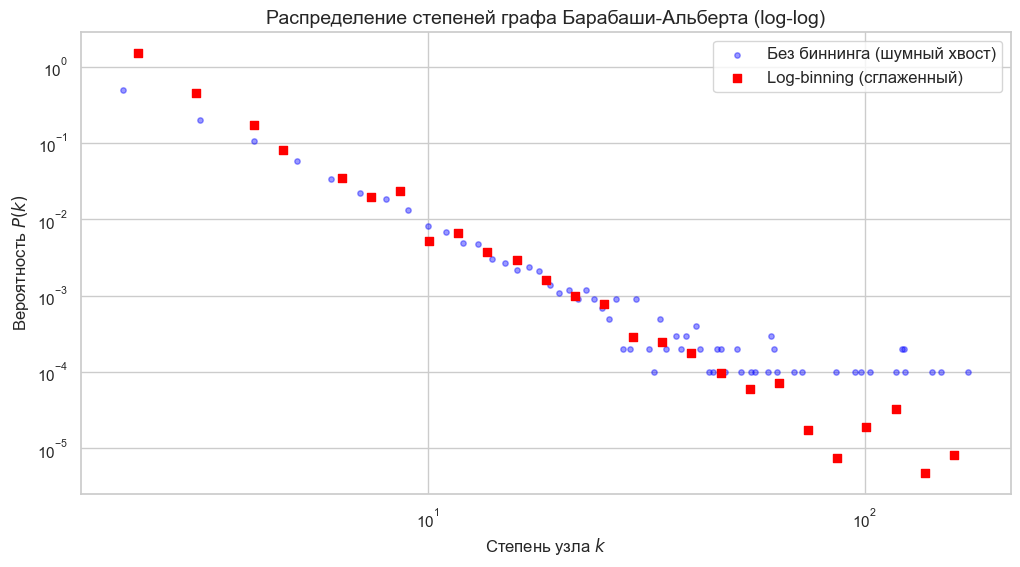

In [41]:
n_nodes = 10000
m_edges = 2
G_ba = nx.barabasi_albert_graph(n=n_nodes, m=m_edges)

degrees =[d for n, d in G_ba.degree()]
degrees = np.array(degrees)


degree_counts = np.bincount(degrees)
degree_values = np.arange(len(degree_counts))

mask = degree_counts > 0
degree_values_filtered = degree_values[mask]
prob_linear = degree_counts[mask] / n_nodes

min_deg, max_deg = degrees.min(), degrees.max()
num_bins = 30
bins = np.logspace(np.log10(min_deg), np.log10(max_deg), num=num_bins)

prob_logbin, bin_edges = np.histogram(degrees, bins=bins, density=True)

bin_centers = (bin_edges[:-1] * bin_edges[1:]) ** 0.5
mask_log = prob_logbin > 0
bin_centers = bin_centers[mask_log]
prob_logbin = prob_logbin[mask_log]


plt.figure(figsize=(12, 6))

plt.scatter(degree_values_filtered, prob_linear, 
            c='blue', alpha=0.4, s=15, label='Без биннинга (шумный хвост)')

plt.scatter(bin_centers, prob_logbin, 
            c='red', marker='s', s=40, label='Log-binning (сглаженный)')

plt.xscale('log')
plt.yscale('log')
plt.title('Распределение степеней графа Барабаши-Альберта (log-log)', fontsize=14)
plt.xlabel('Степень узла $k$', fontsize=12)
plt.ylabel('Вероятность $P(k)$', fontsize=12)
plt.legend(fontsize=12)
plt.show()

3. Возьмите графовый датасет для классификации узлов с числом узлов не менее 1000. Выполните базовый EDA, обучите DeepWalk или Node2Vec, затем классификатор по эмбеддингам и выведите accuracy и macro-F1 на test.


In [42]:
dataset = Planetoid(root='data/Cora', name='Cora')
data = dataset[0]

print(f"Узлов: {data.num_nodes}, Ребер: {data.num_edges}")

edges = data.edge_index.t().tolist()
G = nx.Graph()
G.add_nodes_from(range(data.num_nodes))
G.add_edges_from(edges)

def generate_random_walks(graph: nx.Graph, num_walks: int = 10, walk_length: int = 20) -> List[List[str]]:
    """
    Генерирует случайные блуждания для каждого узла графа.
    Мы переводим ID узлов в строки, так как Word2Vec ожидает "предложения" из "слов".
    """
    walks =[]
    nodes = list(graph.nodes())
    
    print("Генерация случайных блужданий...")
    for walk_iter in range(num_walks):
        random.shuffle(nodes)
        for node in nodes:
            walk = [str(node)]
            current_node = node
            for _ in range(walk_length - 1):
                neighbors = list(graph.neighbors(current_node))
                if len(neighbors) == 0:
                    break
                next_node = random.choice(neighbors)
                walk.append(str(next_node))
                current_node = next_node
            walks.append(walk)
    
    print(f"Сгенерировано {len(walks)} блужданий.")
    return walks

walks = generate_random_walks(G, num_walks=100, walk_length=20)

print("Обучение модели Word2Vec (Skip-Gram) на блужданиях...")
w2v_model = Word2Vec(
    sentences=walks, 
    vector_size=512,
    window=5,
    min_count=0,
    sg=1,
    workers=4,
    epochs=5
)

embeddings = np.array([w2v_model.wv[str(i)] for i in range(data.num_nodes)]) # [Num_Nodes, 128]
labels = data.y.numpy()

train_mask = data.train_mask.numpy()
test_mask = data.test_mask.numpy()

X_train, y_train = embeddings[train_mask], labels[train_mask]
X_test, y_test = embeddings[test_mask], labels[test_mask]


Узлов: 2708, Ребер: 10556
Генерация случайных блужданий...
Сгенерировано 270800 блужданий.
Обучение модели Word2Vec (Skip-Gram) на блужданиях...


In [43]:
clf = SVC(C=0.5, max_iter=100000, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Результаты классификации на Test:")
print(f"Accuracy: {acc:.4f}")
print(f"Macro-F1: {f1:.4f}")

Результаты классификации на Test:
Accuracy: 0.7550
Macro-F1: 0.7545


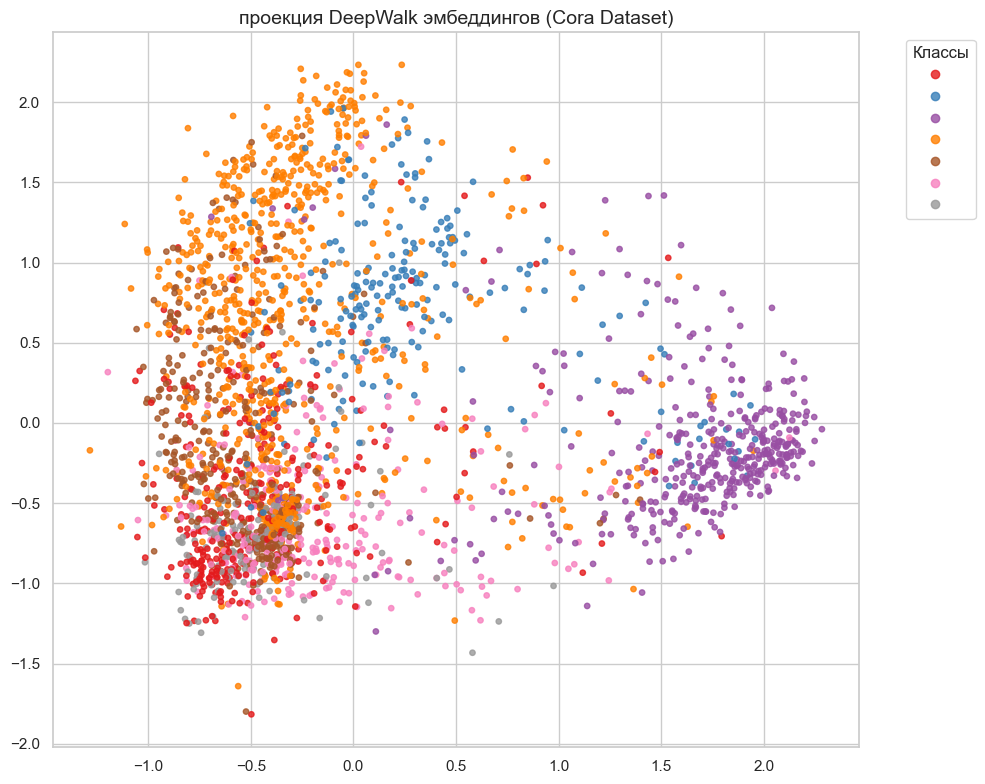

In [44]:
pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels, cmap='Set1', s=15, alpha=0.8)
plt.title('проекция DeepWalk эмбеддингов (Cora Dataset)', fontsize=14)
plt.legend(handles=scatter.legend_elements()[0], title="Классы", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()